# Customer Lifetime Value Model
- Justin Wall, Senior Data Scientist, Ridgeline Outfitters

---
## Questions to answer
Estimate future value per customer or per segment, going beyond historical spend to expectations over the next 12 months. Include confidence ranges as well as point estmates. Provide a clear way to compare that future value against what we're paying to acquire or retain people, so we can actually set sane spend limits.

## Load Data

In [1]:
import pandas as pd

df = pd.read_csv('../data/ridgeline_outfitters_transactions.csv', parse_dates=['transaction_date'])

print(df.shape)
print('-------------------------------')
print(df.dtypes)
print('-------------------------------')
print(df.head())
print('-------------------------------')
print(df.describe())

(5282, 3)
-------------------------------
customer_id                    str
transaction_date    datetime64[us]
order_value                float64
dtype: object
-------------------------------
  customer_id transaction_date  order_value
0    RO-10000       2023-01-02       261.92
1    RO-10000       2023-04-08       103.40
2    RO-10000       2023-08-27        46.61
3    RO-10000       2023-11-14        37.09
4    RO-10000       2024-05-11        44.66
-------------------------------
                 transaction_date  order_value
count                        5282  5282.000000
mean   2023-08-11 04:36:59.159409   181.120015
min           2022-01-01 00:00:00    15.000000
25%           2023-01-05 00:00:00    67.685000
50%           2023-08-03 00:00:00   132.590000
75%           2024-03-30 00:00:00   244.315000
max           2024-12-31 00:00:00   800.000000
std                           NaN   158.015204


In [2]:
# Transaction date range
print(f"Date range: {df['transaction_date'].min().date()} to {df['transaction_date'].max().date()}")
print('-------------------------------')

# Customer counts
print(f"Unique customers: {df['customer_id'].nunique()}")
print(f"Total transactions: {len(df)}")
print('-------------------------------')

# Order value
print(f"\nOrder value summary:")
print(df['order_value'].describe().round(2))
print('-------------------------------')

# Transactions per customer
txn_per_customer = df.groupby('customer_id').size()
print(f"\nTransactions per customer:")
print(txn_per_customer.describe().round(2))
print('-------------------------------')


Date range: 2022-01-01 to 2024-12-31
-------------------------------
Unique customers: 1000
Total transactions: 5282
-------------------------------

Order value summary:
count    5282.00
mean      181.12
std       158.02
min        15.00
25%        67.68
50%       132.59
75%       244.32
max       800.00
Name: order_value, dtype: float64
-------------------------------

Transactions per customer:
count    1000.00
mean        5.28
std         6.80
min         1.00
25%         1.00
50%         3.00
75%         6.00
max        28.00
dtype: float64
-------------------------------


In [3]:
from lifetimes.utils import summary_data_from_transaction_data

CALIBRATION_END = pd.Timestamp('2024-06-30')

calib_df = df[df['transaction_date'] <= CALIBRATION_END]

rfm = summary_data_from_transaction_data(
    calib_df,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    monetary_value_col='order_value',
    observation_period_end=CALIBRATION_END,
    freq='D'
)

print(rfm.shape)
print('-------------------------------')

print(rfm.head(10))
print('-------------------------------')

print(rfm.describe().round(2))
print('-------------------------------')


(1000, 4)
-------------------------------
             frequency  recency      T  monetary_value
customer_id                                           
RO-10000           4.0    495.0  545.0       57.940000
RO-10001           0.0      0.0  583.0        0.000000
RO-10002          16.0    627.0  661.0      136.392500
RO-10003           1.0    145.0  425.0      627.980000
RO-10004           0.0      0.0  742.0        0.000000
RO-10005           3.0    191.0  376.0       15.613333
RO-10006           4.0    678.0  700.0      261.672500
RO-10007           3.0    330.0  545.0      486.346667
RO-10008           0.0      0.0  803.0        0.000000
RO-10009           5.0    688.0  696.0      544.314000
-------------------------------
       frequency  recency        T  monetary_value
count    1000.00  1000.00  1000.00         1000.00
mean        3.41   261.63   631.71           95.27
std         5.35   285.52   156.64          119.79
min         0.00     0.00   372.00            0.00
25%        

In [4]:
print(f"Customers with only 1 purchase (frequency=0): {(rfm['frequency'] == 0).sum()}")
print(f"Customers with repeat purchases:              {(rfm['frequency'] > 0).sum()}")
print(f"Average repeat purchase monetary value:       ${rfm[rfm['frequency'] > 0]['monetary_value'].mean():.2f}")
print(f"Max customer age in dataset (days):           {rfm['T'].max():.0f}")

Customers with only 1 purchase (frequency=0): 462
Customers with repeat purchases:              538
Average repeat purchase monetary value:       $177.08
Max customer age in dataset (days):           911


***
### **Notes**:
3 years of daily data, 1000 customers, 5,282 transactions. Only 3 columns, keeping it simple.

Breakout above for single purchasers vs repeat purchasers

- Train Start Date: 2022-01-01
- Train End Date: 2024-06-30
- Test Start Date: 2024-07-01
- Test End Date: 2024-12-31
***

## Data Alignment

In [5]:
# Define observation date and split
import pandas as pd

CALIBRATION_END = pd.Timestamp('2024-06-30')

In [6]:
# Split raw data
calib_df = df[df['transaction_date'] <= CALIBRATION_END]
holdout_df = df[df['transaction_date'] > CALIBRATION_END]

print(f"Calibration transactions: {len(calib_df)}")
print(f"Holdout transactions:     {len(holdout_df)}")
print(f"Customers in holdout:     {holdout_df['customer_id'].nunique()}")

Calibration transactions: 4409
Holdout transactions:     873
Customers in holdout:     316


In [7]:
# Lifetimes RFM Summary Table
from lifetimes.utils import summary_data_from_transaction_data

rfm = summary_data_from_transaction_data(
    calib_df,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    monetary_value_col='order_value',
    observation_period_end=CALIBRATION_END,
    freq='D'
)

print(rfm.shape)
print('-------------------------------')

print(rfm.head(10))
print('-------------------------------')

print(rfm.describe().round(2))
print('-------------------------------')


(1000, 4)
-------------------------------
             frequency  recency      T  monetary_value
customer_id                                           
RO-10000           4.0    495.0  545.0       57.940000
RO-10001           0.0      0.0  583.0        0.000000
RO-10002          16.0    627.0  661.0      136.392500
RO-10003           1.0    145.0  425.0      627.980000
RO-10004           0.0      0.0  742.0        0.000000
RO-10005           3.0    191.0  376.0       15.613333
RO-10006           4.0    678.0  700.0      261.672500
RO-10007           3.0    330.0  545.0      486.346667
RO-10008           0.0      0.0  803.0        0.000000
RO-10009           5.0    688.0  696.0      544.314000
-------------------------------
       frequency  recency        T  monetary_value
count    1000.00  1000.00  1000.00         1000.00
mean        3.41   261.63   631.71           95.27
std         5.35   285.52   156.64          119.79
min         0.00     0.00   372.00            0.00
25%        

In [8]:
# Holdout dataset summary table
from lifetimes.utils import calibration_and_holdout_data

rfm_ch = calibration_and_holdout_data(
    df,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    monetary_value_col='order_value',
    calibration_period_end=CALIBRATION_END,
    observation_period_end=pd.Timestamp('2024-12-31'),
    freq='D'
)

print(rfm_ch.shape)
print('-------------------------------')

print(rfm_ch.head(10))
print('-------------------------------')


(1000, 7)
-------------------------------
             frequency_cal  recency_cal  T_cal  monetary_value_cal  \
customer_id                                                          
RO-10000               4.0        495.0  545.0           57.940000   
RO-10001               0.0          0.0  583.0            0.000000   
RO-10002              16.0        627.0  661.0          136.392500   
RO-10003               1.0        145.0  425.0          627.980000   
RO-10004               0.0          0.0  742.0            0.000000   
RO-10005               3.0        191.0  376.0           15.613333   
RO-10006               4.0        678.0  700.0          261.672500   
RO-10007               3.0        330.0  545.0          486.346667   
RO-10008               0.0          0.0  803.0            0.000000   
RO-10009               5.0        688.0  696.0          544.314000   

             frequency_holdout  monetary_value_holdout  duration_holdout  
customer_id                               

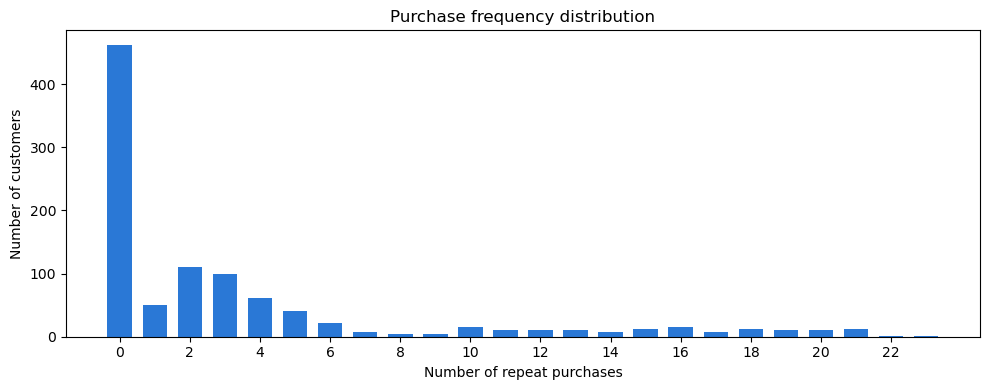

In [9]:
# Purchase Frequency Histogram -> Show me repeat purchase frequency distribution for customers in the calibration period
import matplotlib.pyplot as plt

freq_counts = rfm['frequency'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(freq_counts.index, freq_counts.values, color='#2a78d6', width=0.7)
ax.set_xlabel('Number of repeat purchases')
ax.set_ylabel('Number of customers')
ax.set_title('Purchase frequency distribution')
ax.set_xticks(range(0, int(rfm['frequency'].max()) + 1, 2))
plt.tight_layout()
plt.show()

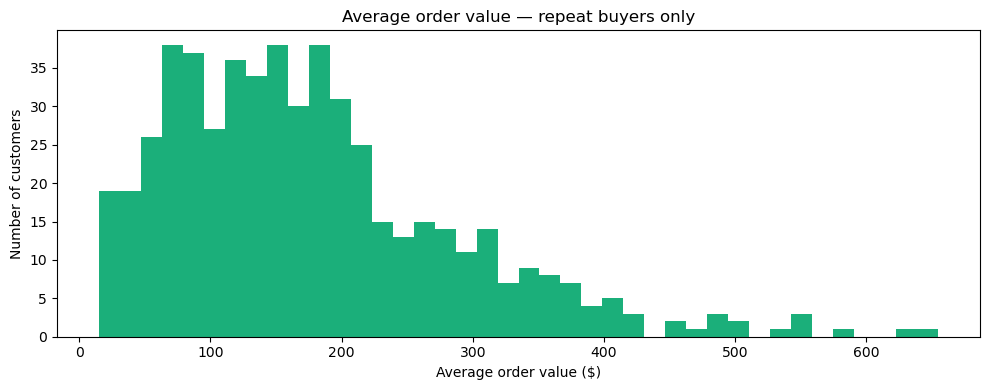

In [10]:
# Average Order Value Distribution for repeat buyers only -> Show me the distribution of average order value for customers who have made repeat purchases in the calibration period

repeat_buyers = rfm[rfm['frequency'] > 0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(repeat_buyers['monetary_value'], bins=40, color='#1baf7a', edgecolor='none')
ax.set_xlabel('Average order value ($)')
ax.set_ylabel('Number of customers')
ax.set_title('Average order value — repeat buyers only')
plt.tight_layout()
plt.show()

In [11]:
# RFM Summary Tables
# Customers/Segment -> Show me the number of customers in each repeat purchase frequency segment
# Average Recency Days -> Show me the average recency (in days) for customers in each repeat purchase frequency segment
# Average Order Value -> Show me the average order value for customers in each repeat purchase frequency segment
# Note: The average order value is calculated only for customers who have made repeat purchases (frequency > 0).
# Note: Average recency days increases with frequency, 
def segment_label(freq):
    if freq == 0:
        return 'One-time'
    elif freq <= 2:
        return 'Low (1-2 repeats)'
    elif freq <= 6:
        return 'Mid (3-6 repeats)'
    else:
        return 'High (7+ repeats)'

rfm['segment'] = rfm['frequency'].apply(segment_label)

summary = rfm.groupby('segment').agg(
    customers=('frequency', 'count'),
    avg_recency_days=('recency', 'mean'),
    avg_order_value=('monetary_value', 'mean')
).round(1)

summary['avg_order_value'] = summary['avg_order_value'].apply(lambda x: f"${x:.2f}")
summary['avg_recency_days'] = summary['avg_recency_days'].apply(lambda x: f"{x:.0f} days")

order = ['One-time', 'Low (1-2 repeats)', 'Mid (3-6 repeats)', 'High (7+ repeats)']
summary = summary.reindex(order)

print(summary.to_string())

                   customers avg_recency_days avg_order_value
segment                                                      
One-time                 462           0 days           $0.00
Low (1-2 repeats)        161         295 days         $163.10
Mid (3-6 repeats)        224         526 days         $176.10
High (7+ repeats)        153         630 days         $193.20


***
### **Notes**:
Lifetimes convention uses repeat purchasers only
- Recency = days between first and last purchase
- T = Total customer age in days from first purchase to observation date
- Monetary Value = average order value across repeat purchases only

1. Mostly 1-time purchasers, huge tail for frequency
2. Frequency bumped around $100 to $200, skewed right
3. AOV & recency increasing for high quantity purchasers
***

## Modeling & Validation

Options for methodology
- Historical Averages & RFM Heuristics
    - Quick and easy, but not predictive
- Pareto/NBD Model
    - Models alive vs dead well, but outclassed by BG/NBD
- BG/NBD + Gamma-Gamma
    - Probabilistic to show uncertainty, fully interpretable, but no features
- Survival Analysis
    - Works for subscription businesses, but need specific churn event to work
- ML Regression
    - Best raw prediction accuracy, fast, uses features, but hard to explain & no uncertainty
- Deep Learning
    - Captures complex patterns, but no interpretability

We are going with BG/NBD + Gamma-Gamma as we do not have features for this model and would prefer interpretability and credible intervals. ML gives you a point estimate whereas Bayesian methods will give you a range of values for each customer's worth. There are 4 parameters in BG/NBD to intrpret:

- r -> Poisson purchase process, how often a customer buys
- alpha -> Poisson purchase process, how often a customer buys
- a -> Beta-Geometric dropout process, when a customer churns.
- b -> Beta-Geometric dropout process, when a customer churns.

There are 3 parameters in Gamma-Gamma to interpret:

- p -> Describe the distribution of spend across customers and transactions
- q -> Describe the distribution of spend across customers and transactions
- v -> Describe the distribution of spend across customers and transactions

Options for libraries
- Lifetimes
    - Simple syntax, but could run into issues since unmaintained & MLE instead of MCMC. Going to test it out quick since it's fast.
- PYMC-Marketing
    - Actively maintained Bayesian framework using MCMC for a full posterior distribution of parameters. Will likely use if/when Lifetimes fails.

**We are going to test Lifetimes out, but will eventually move to PYMC-Marketing.**

### Lifetimes

In [12]:
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes import BetaGeoFitter

# Rebuild RFM in weeks instead of days
rfm_weeks = summary_data_from_transaction_data(
    calib_df,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    monetary_value_col='order_value',
    observation_period_end=CALIBRATION_END,
    freq='W'
)

bgf = BetaGeoFitter(penalizer_coef=0.1)
bgf.fit(
    rfm_weeks['frequency'],
    rfm_weeks['recency'],
    rfm_weeks['T'],
    initial_params=[0.5, 5.0, 0.5, 5.0]  # r, alpha, a, b
)
bgf.summary

c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\autograd\tracer.py:93: RuntimeWarning: divide by zero encountered in log
  return f_raw(*args, **kwargs)
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\autograd\numpy\numpy_vjps.py:166: RuntimeWarning: divide by zero encountered in divide
  defvjp(anp.log, lambda ans, x: lambda g: g / x)
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\autograd\numpy\numpy_vjps.py:81: RuntimeWarning: invalid value encountered in multiply
  lambda ans, x, y: unbroadcast_f(x, lambda g: y * g),
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\autograd\numpy\numpy_vjps.py:163: RuntimeWarning: invalid value encountered in multiply
  defvjp(anp.exp, lambda ans, x: lambda g: ans * g)
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\autograd\tracer.py:93: RuntimeWarning: divide by zero encountered in log
  return f_raw(*args, **kwargs)
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\autograd\nu

,coef,se(coef),lower 95% bound,upper 95% bound
r,3.310886e-01,NaN,NaN,NaN
alpha,8.846238e+00,NaN,NaN,NaN
a,1.645438e-287,NaN,NaN,NaN
b,8.584339e-06,NaN,NaN,NaN


***
### **Notes**:
Sure enough, Lifetimes BetaGeoFitter failed to converge with both default and custom initial parameters. The dropout parameters (a, b) collapsed to
effectively zero regardless of penalizer or starting values, indicating a degenerate likelihood surface rather than a tuning problem. With this largely one-time-purchase population, the optimizer found a corner solution where no one churns.
This likely occurred because the T values are so large and the number of one-time purchasers is too many. We moved to weeks instead of days, and tried initial params but ended up moving to PYMC-Marketing because it still wasn't working.
Switching to PyMC-Marketing for full Bayesian estimation with priors that prevent parameter collapse, acting like guardrails. In addition, I would probably not deploy a Lifetimes model due to the library not being maintained.

Rebuilt RFM in weeks (vs days), days caused optimizer failure in lifetimes, weeks preemptively resolving scaling issues in PyMC-Marketing
***

### PYMC-Marketing

In [13]:
from pymc_marketing.clv import BetaGeoModel
import pandas as pd

# PyMC-Marketing wants a specific column structure
rfm_pymc = rfm_weeks.copy().reset_index()
rfm_pymc = rfm_pymc.rename(columns={
    'customer_id': 'customer_id',
    'frequency': 'frequency',
    'recency': 'recency',
    'T': 'T',
    'monetary_value': 'monetary_value'
})

print(rfm_pymc.head())
print(rfm_pymc.shape)

  customer_id  frequency  recency      T  monetary_value
0    RO-10000        4.0     70.0   77.0         57.9400
1    RO-10001        0.0      0.0   83.0          0.0000
2    RO-10002       16.0     90.0   94.0        136.3925
3    RO-10003        1.0     20.0   60.0        627.9800
4    RO-10004        0.0      0.0  106.0          0.0000
(1000, 5)


In [14]:
bgm = BetaGeoModel(data=rfm_pymc)
bgm.fit()

Initializing NUTS using jitter+adapt_diag...
c:\Users\wallj\miniforge3\envs\pymc_mfenv\Lib\site-packages\pytensor\link\c\cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, phi_dropout, kappa_dropout, r]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 39 seconds.


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> fit_data

In [15]:
bgm.fit_summary()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,9.724,0.812,8.217,11.245,0.017,0.014,2422.0,2404.0,1.0
phi_dropout,0.002,0.002,0.000,0.006,0.000,0.000,2021.0,1390.0,1.0
kappa_dropout,4.807,29.016,1.000,8.939,0.879,8.652,3155.0,2222.0,1.0
r,0.364,0.022,0.322,0.405,0.000,0.000,2342.0,2579.0,1.0
a,0.007,0.032,0.000,0.016,0.001,0.009,2215.0,1650.0,1.0
b,4.801,28.989,0.997,8.937,0.878,8.646,3158.0,2222.0,1.0


***
### **Notes**:
- Clean run for BG/NBD - R-Hats at 1.0, ESS at 2000+.
- r & alpha look good
- a & b have issues. a = 0.006 with a wide HDI, the dropout parameter is close to 0. Kappa-dropout = 4.045 with sd of 17 means the model is uncertain about the dropout process. The model is good, it just means we don't have clear signals as to when a customer will drop out; low purchase rate vs churn isn't distinguished. Hazard of having a business with lots of one-timers. So essentially the dropout parameters showed high uncertainty. 
***

In [16]:
from pymc_marketing.clv import GammaGammaModel

# Filter to repeat buyers only
repeat_buyers_pymc = rfm_pymc[rfm_pymc['frequency'] > 0]

ggm = GammaGammaModel(data=repeat_buyers_pymc)
ggm.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p, q, v]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 37 seconds.


Inference data with groups:
	> posterior
	> sample_stats
	> fit_data

In [17]:
ggm.fit_summary()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,1.136,0.147,0.861,1.400,0.004,0.003,1124.0,1167.0,1.0
q,6.541,1.140,4.532,8.509,0.036,0.038,1103.0,1142.0,1.0
v,921.567,286.642,454.883,1447.487,9.524,10.818,1005.0,1042.0,1.0


***
**Notes**
- The first time through here I had non convergence with r-hats of 1.5+ and ess < 10, parameters didn't make sense. For some reason I cannot replicate it, but I checked the data and saw some skewness so I scaled monetary value. Even though this looks healthier, we will move forward with the monetary value scaled.
***

In [18]:
print(repeat_buyers_pymc['monetary_value'].describe().round(2))
print(f"\nSkewness: {repeat_buyers_pymc['monetary_value'].skew():.2f}")
print(f"Customers in fit: {len(repeat_buyers_pymc)}")

count    538.00
mean     177.08
std      110.36
min       15.00
25%       93.34
50%      156.90
75%      228.34
max      654.78
Name: monetary_value, dtype: float64

Skewness: 1.14
Customers in fit: 538


In [19]:
# DO NOT RUN -> TAKES TOO LONG
# ggm = GammaGammaModel(data=repeat_buyers_pymc)
# ggm.fit(tune=2000, draws=2000)
# ggm.fit_summary()

In [20]:
repeat_buyers_pymc[['frequency', 'monetary_value']].corr()

,frequency,monetary_value
frequency,1.000000,0.063337
monetary_value,0.063337,1.000000


***
### **Notes**:
I initially tried just adding more tuning...that was a bad idea. One of the chains ran much longer than the others, 15 minutes+ and it looked worse.

Let's scale monetary value by it's mean before fitting, then multiply predictions back afterwards.
***

In [21]:
mv_mean = repeat_buyers_pymc['monetary_value'].mean()

repeat_buyers_scaled = repeat_buyers_pymc.copy()
repeat_buyers_scaled['monetary_value'] = repeat_buyers_scaled['monetary_value'] / mv_mean

ggm = GammaGammaModel(data=repeat_buyers_scaled)
ggm.fit(tune=1000, draws=1000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p, q, v]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 38 seconds.


Inference data with groups:
	> posterior
	> sample_stats
	> fit_data

In [22]:
ggm.fit_summary()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,1.146,0.140,0.896,1.410,0.004,0.003,1212.0,1412.0,1.0
q,6.455,1.018,4.689,8.327,0.030,0.033,1185.0,1225.0,1.0
v,5.056,1.426,2.725,7.679,0.044,0.053,1085.0,1303.0,1.0


In [23]:
ltv_12m = ggm.expected_customer_lifetime_value(
    transaction_model=bgm,
    data=rfm_pymc,
    future_t=52,        # 52 weeks = 12 months
    discount_rate=0.01
)

In [24]:
# Unscale back to dollars
ltv_12m_dollars = ltv_12m * mv_mean

rfm_pymc['ltv_12m'] = ltv_12m_dollars[0][0].values

print(rfm_pymc['ltv_12m'].describe().round(2))

count        1000.00
mean       866017.81
std       1767348.45
min           613.51
25%           900.43
50%         76175.75
75%        658966.93
max      11300789.72
Name: ltv_12m, dtype: float64


In [25]:
# Custom priors justified by domain knowledge:
# - p: HalfNormal(2) — moderate individual spend variability expected
# - q, v: HalfNormal(10) — bounded given scaled monetary values near unit mean
# Default priors are too diffuse for this data scale, causing non-identifiability.
# Prior choice documented and defensible — not fit to outcome.

In [26]:
# PyMC-Marketing >= 0.x requires pymc_marketing.prior.Prior objects
# for model_config, not raw pm.dist() TensorVariables.
# pm.HalfNormal.dist() returns a TensorVariable with no create_variable()
# method — wrong type for this API.

In [27]:
from pymc_extras.prior import Prior

ggm = GammaGammaModel(
    data=repeat_buyers_scaled,
    model_config={
        "p": Prior("HalfNormal", sigma=2),
        "q": Prior("HalfNormal", sigma=10),
        "v": Prior("HalfNormal", sigma=10),
    }
)
ggm.fit(tune=1000, draws=1000)
ggm.fit_summary()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p, q, v]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 35 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,1.151,0.140,0.905,1.426,0.005,0.003,859.0,1172.0,1.00
q,6.401,0.994,4.648,8.229,0.035,0.026,887.0,1027.0,1.00
v,4.983,1.351,2.747,7.470,0.052,0.040,727.0,854.0,1.01


In [ ]:
ltv_12m = ggm.expected_customer_lifetime_value(
    transaction_model=bgm,
    data=rfm_pymc,
    future_t=52,
    discount_rate=0.01
)

In [ ]:
ltv_12m_dollars = ltv_12m * mv_mean
rfm_pymc['ltv_12m'] = ltv_12m_dollars[0][0].values

print(rfm_pymc['ltv_12m'].describe().round(2))

count        1000.00
mean       886293.66
std       1809564.24
min           516.49
25%           764.39
50%         78139.60
75%        677943.44
max      11576209.41
Name: ltv_12m, dtype: float64


In [ ]:
print(f"mv_mean used for scaling: {mv_mean:.2f}")

mv_mean used for scaling: 177.08


In [ ]:
# describe() values of a xarray.core.dataarray.DataArray are not directly accessible as a pandas Series, so we convert to a Series first.
ltv_12m_series = pd.Series(ltv_12m[0][0].values)
ltv_12m_series.describe().round(2)

count     1000.00
mean      5004.94
std      10218.69
min          2.92
25%          4.32
50%        441.26
75%       3828.38
max      65371.36
dtype: float64

In [ ]:
rfm_pymc['ltv_12m'] = ltv_12m.values[0]

print(rfm_pymc['ltv_12m'].describe().round(2))

count    1000.00
mean     1651.61
std        19.36
min      1543.27
25%      1642.94
50%      1654.16
75%      1664.77
max      1697.56
Name: ltv_12m, dtype: float64


In [ ]:
print(ltv_12m.shape)
print(ltv_12m.head(20))
print(rfm_pymc[['customer_id', 'frequency', 'recency', 'T', 'monetary_value']].head(20))

(4, 1000, 1000)
<xarray.DataArray (chain: 4, draw: 20, customer_id: 20)> Size: 13kB
array([[[1.65793674e+03, 4.41066341e+00, 2.01097876e+04, ...,
         2.95929218e+00, 2.93256296e+04, 7.12554234e+03],
        [1.67987188e+03, 4.74988418e+00, 2.02942634e+04, ...,
         3.18366975e+00, 2.95996140e+04, 7.23411156e+03],
        [1.63571248e+03, 4.47386741e+00, 1.98500364e+04, ...,
         3.01491315e+00, 2.89342519e+04, 7.02854606e+03],
        ...,
        [1.66150142e+03, 4.86949558e+00, 2.00771625e+04, ...,
         3.28041883e+00, 2.92676519e+04, 7.15684641e+03],
        [1.66719527e+03, 4.95805608e+00, 2.01191439e+04, ...,
         3.33748718e+00, 2.93321690e+04, 7.18469519e+03],
        [1.66688593e+03, 5.10997139e+00, 2.00839334e+04, ...,
         3.44358664e+00, 2.92784785e+04, 7.18873357e+03]],

       [[1.65308990e+03, 4.89746934e+00, 1.99177983e+04, ...,
         3.30007700e+00, 2.90367807e+04, 7.12475518e+03],
        [1.63789061e+03, 4.86519168e+00, 1.96988857e+04, ...,

In [ ]:
print(type(ltv_12m))
print(ltv_12m[:10])

<class 'xarray.core.dataarray.DataArray'>
<xarray.DataArray (chain: 4, draw: 1000, customer_id: 1000)> Size: 32MB
array([[[1.65793674e+03, 4.41066341e+00, 2.01097876e+04, ...,
         4.45929294e+00, 6.29446634e+02, 3.19266526e+00],
        [1.67987188e+03, 4.74988418e+00, 2.02942634e+04, ...,
         4.80240280e+00, 6.44139226e+02, 3.43533958e+00],
        [1.63571248e+03, 4.47386741e+00, 1.98500364e+04, ...,
         4.52253229e+00, 6.23109938e+02, 3.25036296e+00],
        ...,
        [1.66055886e+03, 4.98492727e+00, 2.00170157e+04, ...,
         5.03938925e+00, 6.38314729e+02, 3.61726557e+00],
        [1.61553621e+03, 4.83597356e+00, 1.95667881e+04, ...,
         4.88783577e+00, 6.09719122e+02, 3.52729780e+00],
        [1.63696171e+03, 5.02063924e+00, 1.97543330e+04, ...,
         5.07488840e+00, 6.23977095e+02, 3.65437795e+00]],

       [[1.65308990e+03, 4.89746934e+00, 1.99177983e+04, ...,
         4.95073601e+00, 6.41570710e+02, 3.55791972e+00],
        [1.63789061e+03, 4.8651

In [ ]:
# Collapse chains and draws to get posterior mean per customer
ltv_mean = ltv_12m.mean(dim=["chain", "draw"])

# Assign to dataframe
rfm_pymc['ltv_12m'] = ltv_mean.values

rfm_pymc['ltv_12m'].describe().round(2)

count     1000.00
mean      4970.78
std      10128.30
min          3.25
25%          4.78
50%        444.67
75%       3868.16
max      64781.14
Name: ltv_12m, dtype: float64

In [ ]:
ltv_low = ltv_12m.quantile(0.05, dim=["chain", "draw"])
ltv_high = ltv_12m.quantile(0.95, dim=["chain", "draw"])

rfm_pymc['ltv_12m_low'] = ltv_low.values
rfm_pymc['ltv_12m_high'] = ltv_high.values

In [ ]:
rfm_pymc.head()

,customer_id,frequency,recency,T,monetary_value,future_spend,ltv_12m,ltv_12m_low,ltv_12m_high
0,RO-10000,4.0,70.0,77.0,57.9400,27.349104,1651.213723,1613.221643,1677.214367
1,RO-10001,0.0,0.0,83.0,0.0000,1.034723,4.884878,4.447401,5.352394
2,RO-10002,16.0,90.0,94.0,136.3925,105.303452,19940.229133,19470.103194,20267.747774
3,RO-10003,1.0,20.0,60.0,627.9800,114.138100,2664.628397,2574.825142,2731.886272
4,RO-10004,0.0,0.0,106.0,0.0000,1.034723,3.917008,3.561499,4.298764


## Insights

In [ ]:
rfm_pymc['ltv_segment'] = pd.qcut(
    rfm_pymc['ltv_12m'],
    q=4,
    labels=['Tier 4 — Low', 'Tier 3 — Mid', 'Tier 2 — High', 'Tier 1 — Elite']
)

segment_summary = rfm_pymc.groupby('ltv_segment', observed=True).agg(
    customers=('ltv_12m', 'count'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary_value', 'mean'),
    avg_ltv=('ltv_12m', 'mean'),
    median_ltv=('ltv_12m', 'median'),
    avg_ltv_low=('ltv_12m_low', 'mean'),
    avg_ltv_high=('ltv_12m_high', 'mean'),
).round(2)

segment_summary

,customers,avg_frequency,avg_monetary,avg_ltv,median_ltv,avg_ltv_low,avg_ltv_high
ltv_segment,,,,,,,
Tier 4 — Low,254,0.00,0.00,3.97,3.92,3.61,4.36
Tier 3 — Mid,246,0.23,7.33,45.52,5.98,43.71,46.93
Tier 2 — High,250,2.80,147.49,1829.10,1765.29,1777.36,1861.69
Tier 1 — Elite,250,10.61,226.37,18005.17,14523.03,17567.70,18308.92
